In [12]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from indoor_plant_preprocessing import preprocessing

In [13]:
data, data_optimal = preprocessing()

optimal_features = [
    "Optimal_Room_Temperature_C",
    "Optimal_Humidity_%",
    "Optimal_Soil_Moisture_%",
    "Optimal_Light_Intensity_Lux",
]

In [15]:
# Scaling
# scaler = StandardScaler()
#
# X_train_scaled = pd.DataFrame(
#     scaler.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )
#
# X_test_scaled = pd.DataFrame(
#     scaler.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )
#
# X_train_scaled

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(data_optimal[optimal_features]),
    columns=optimal_features,
    index=data_optimal.index,
)

X_scaled

,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux
0,0.356034,0.210183,0.291077,-0.818911
1,0.356034,-1.700568,-1.763585,1.716416
2,1.542816,1.356633,0.975964,0.702286
3,-0.830747,0.592333,0.633521,0.195220
4,0.356034,1.356633,1.318408,-1.072443
5,-2.017529,-0.171968,-0.051367,-0.311845
6,1.542816,0.210183,0.291077,1.969949
7,0.356034,0.592333,0.633521,-0.058313
8,-0.830747,-1.318418,-1.421141,0.955818
9,0.356034,0.210183,0.291077,-0.565378


In [5]:
# # Columns to normalize
# normalize_cols = ["light_deviation", "et_approx"]
#
# # Normalize
# pt = PowerTransformer(method='yeo-johnson')
#
# X_train[normalize_cols] = pt.fit_transform(X_train[normalize_cols])
#
# X_test[normalize_cols] = pt.transform(X_test[normalize_cols])
#
# X_train.head()

,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux,Light_Intensity,Pump_time,soil_deficit,temp_deviation,air_hum_deficit,light_deviation,et_approx
29,25.8,39.4,28.0,24,35,25,250,100,20.5,-3.0,1.8,-4.4,-0.763176,-1.389339
535,27.9,41.7,57.7,23,65,60,550,355,31.1,2.3,4.9,23.3,-0.866617,-0.170882
695,25.2,67.7,55.9,23,50,45,633,96,38.9,-10.9,2.2,-17.7,-1.640903,-1.713644
557,23.3,60.2,43.9,24,65,60,500,755,16.5,16.1,-0.7,4.8,0.311420,0.131985
836,29.9,64.1,42.9,25,60,55,900,195,40.9,12.1,4.9,-4.1,-2.016700,-1.149978


In [6]:
data = data.drop(columns=['Plant_ID'])
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(data)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

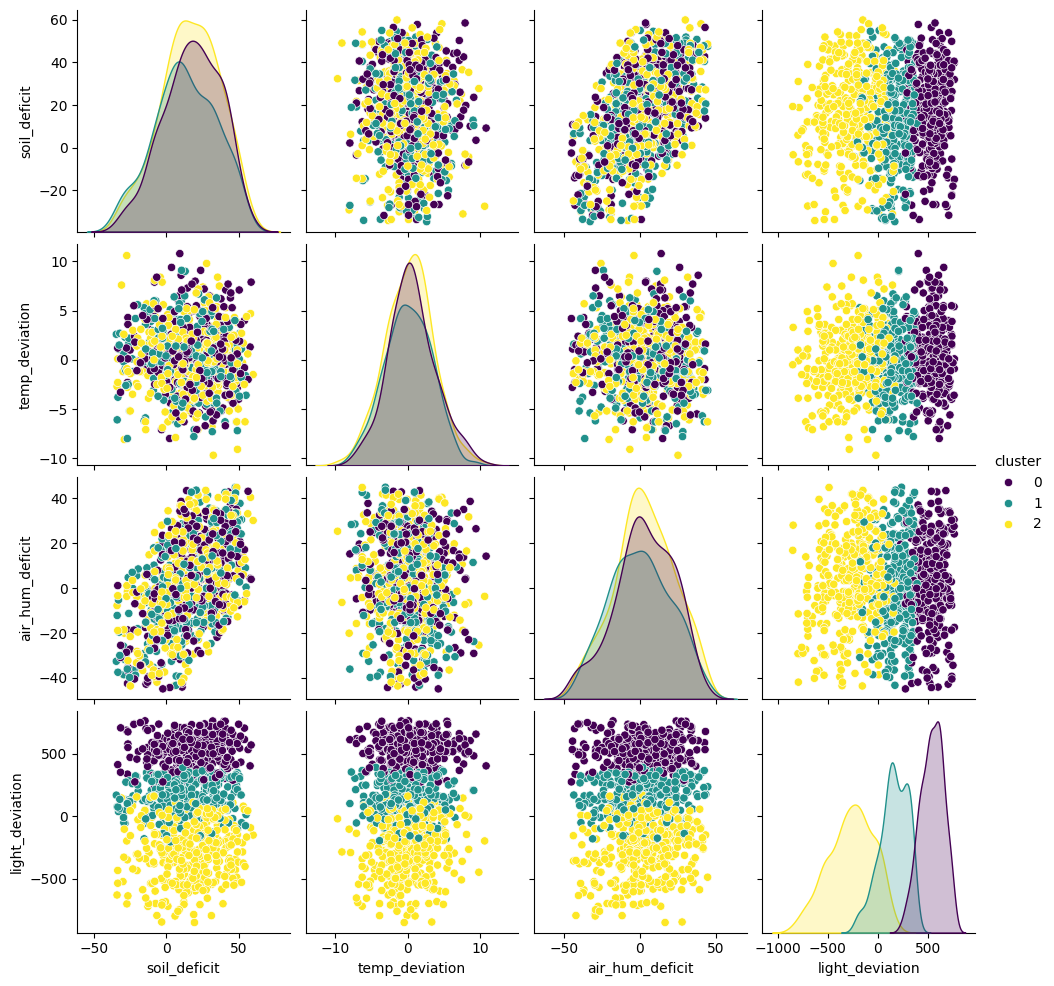

In [7]:
import seaborn as sns

features = [
    'soil_deficit',
    'temp_deviation',
    'air_hum_deficit',
    'light_deviation'
]

plot_data = data[features].copy()
plot_data['cluster'] = labels

sns.pairplot(
    plot_data,
    hue='cluster',
    palette='viridis'
)

plt.show()

<Figure size 1500x1000 with 0 Axes>

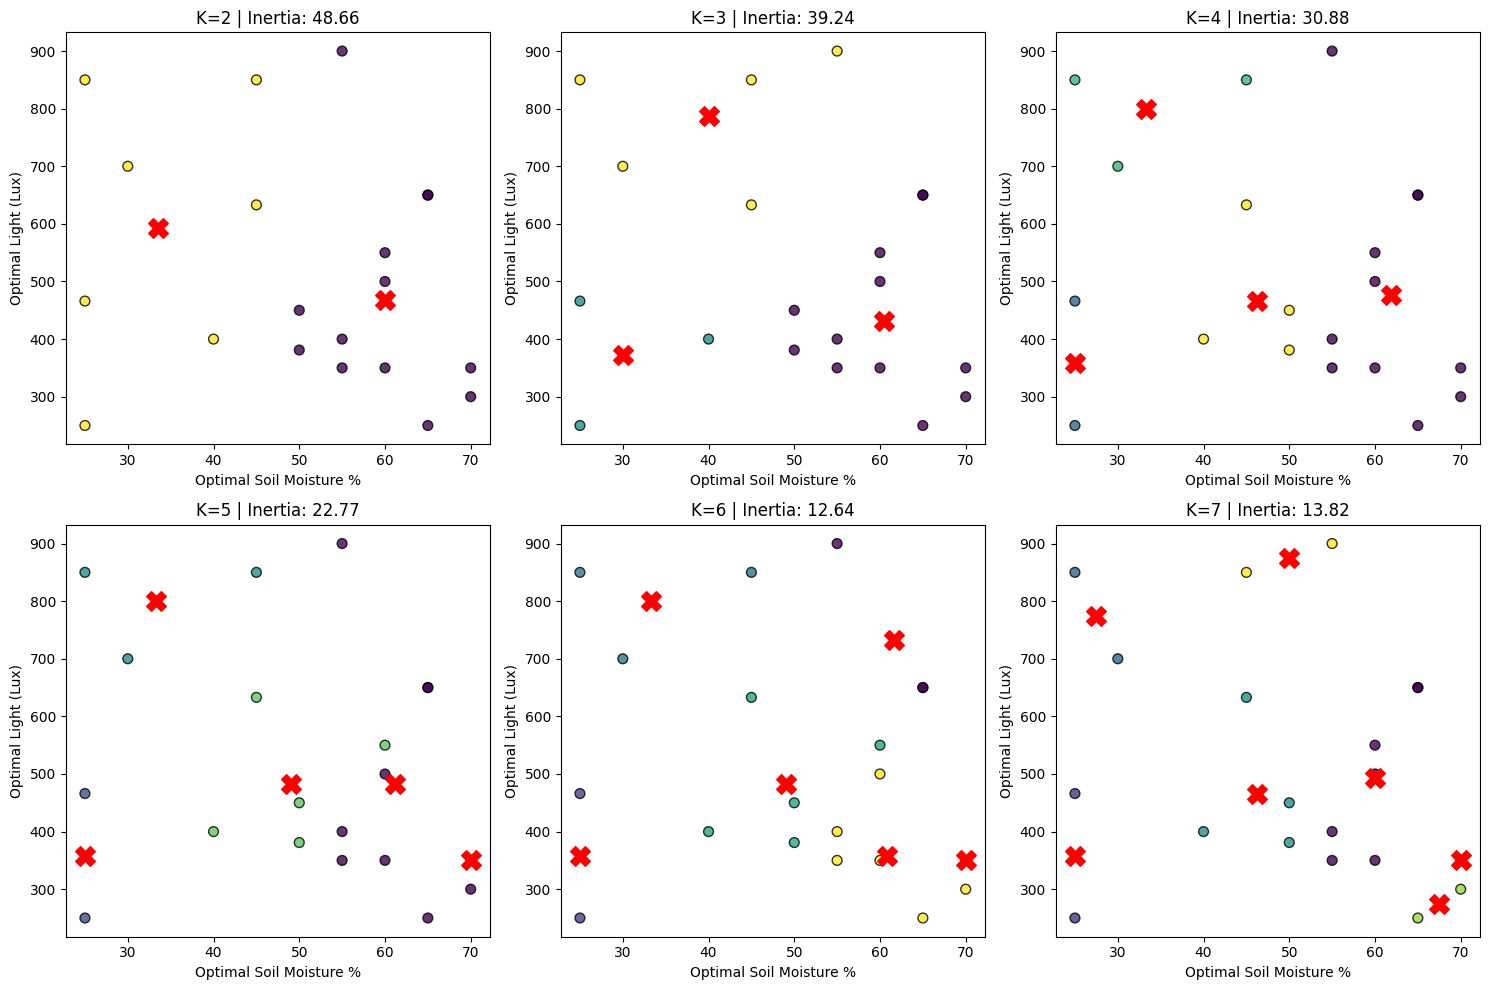

In [27]:
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4, 5, 6, 7]
inertias = []
silhouettes = []

plt.figure(figsize=(15, 10))

plt.figure(figsize=(15, 10))
for i, k in enumerate(k_values):
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

    centroids = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=optimal_features, )

    plt.subplot(2, 3, i + 1)
    plt.scatter(
        data_optimal["Optimal_Soil_Moisture_%"],
        data_optimal["Optimal_Light_Intensity_Lux"],
        c=labels, cmap='viridis', s=50, edgecolors='k', alpha=0.8,
    )
    plt.scatter(
        centroids["Optimal_Soil_Moisture_%"],
        centroids["Optimal_Light_Intensity_Lux"],
        marker='X', s=200, c='red', label='Centroids'
    )
    plt.title(f"K={k} | Inertia: {km.inertia_:.2f}")
    plt.xlabel("Optimal Soil Moisture %")
    plt.ylabel("Optimal Light (Lux)")
plt.tight_layout()
plt.show()

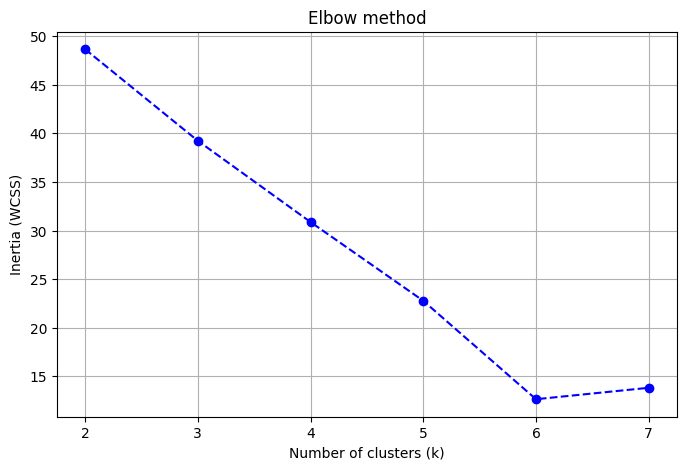

In [22]:
# elbow method plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow method')
plt.xticks(k_values)
plt.grid(True)
plt.show()

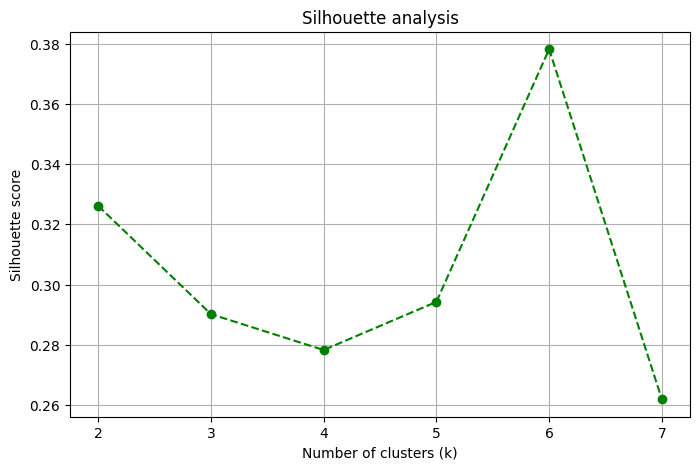

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouettes, marker='o', linestyle='--', color='g')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette analysis')
plt.xticks(k_values)
plt.grid(True)
plt.show()